In [81]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

In [82]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [83]:
tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "JPM", "XOM", "SPY"]
start_date = "2015-01-01"
end_date = "2026-08-23"

data = yf.download(tickers, start=start_date, end=end_date, auto_adjust=True)
close_prices = data["Close"].dropna()
volumes = data["Volume"].dropna()

print(close_prices.shape)
close_prices.head()

[*********************100%***********************]  7 of 7 completed


(2926, 7)


Ticker,AAPL,AMZN,GOOGL,JPM,MSFT,SPY,XOM
Date,,,,,,,
2015-01-02,24.171751,15.4260,26.244783,46.066799,39.607174,169.687851,56.777901
2015-01-05,23.490799,15.1095,25.744715,44.636646,39.242966,166.623306,55.224358
2015-01-06,23.493017,14.7645,25.109350,43.479267,38.666992,165.053894,54.930782
2015-01-07,23.822430,14.9210,25.035503,43.545597,39.158245,167.110718,55.487362
2015-01-08,24.737741,15.0230,25.122734,44.518684,40.310207,170.076035,56.410942


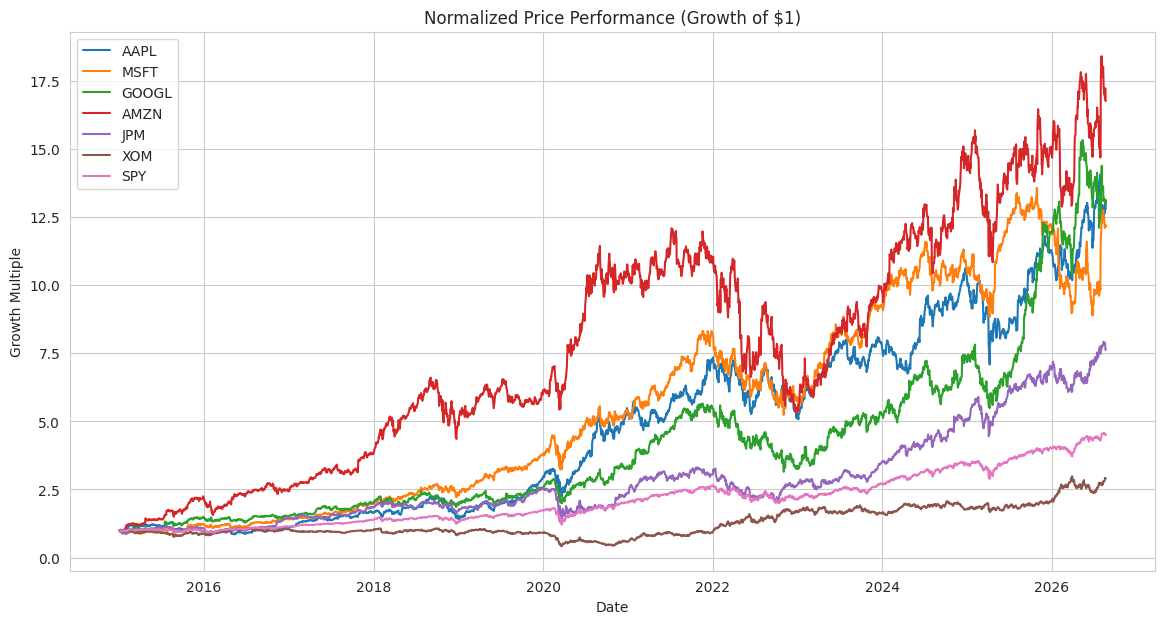

In [84]:
plt.figure(figsize=(14,7))
for ticker in tickers:
    plt.plot(close_prices.index, close_prices[ticker] / close_prices[ticker].iloc[0], label=ticker)
plt.title("Normalized Price Performance (Growth of $1)")
plt.xlabel("Date")
plt.ylabel("Growth Multiple")
plt.legend()
plt.savefig("Normalized Price Performance.png", dpi=150, bbox_inches="tight")
plt.show()

In [85]:
returns = close_prices.pct_change().dropna()

from statsmodels.tsa.stattools import adfuller

result = adfuller(close_prices["SPY"].dropna())
print("ADF p-value (raw prices):", result[1])

result2 = adfuller(returns["SPY"].dropna())
print("ADF p-value (returns):", result2[1])

ADF p-value (raw prices): 0.9982126943951325
ADF p-value (returns): 3.491664874391409e-30


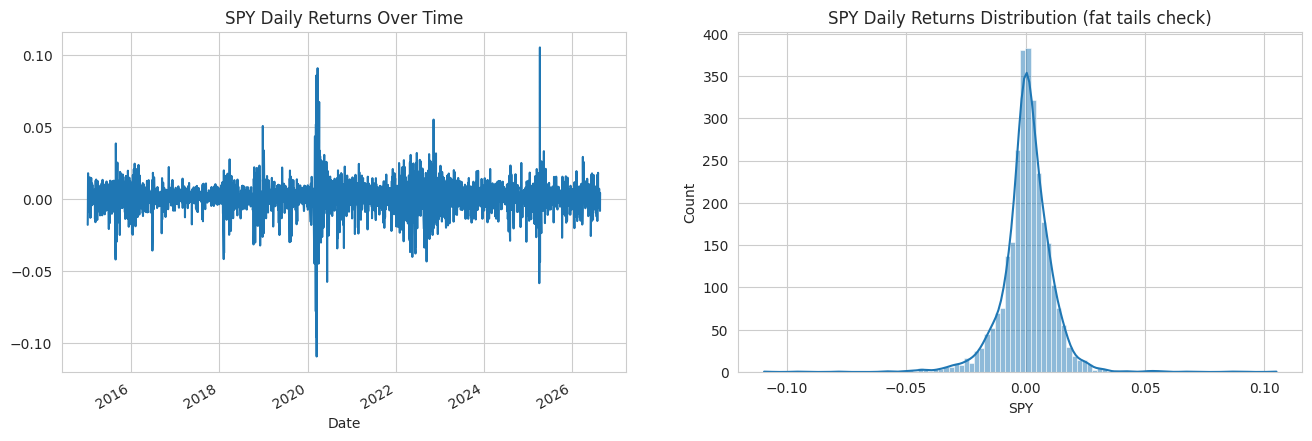

Skewness: -0.307071611925658
Kurtosis: 14.06008380183824


In [86]:
fig, axes = plt.subplots(1, 2, figsize=(16,5))
returns["SPY"].plot(ax=axes[0], title="SPY Daily Returns Over Time")
sns.histplot(returns["SPY"], bins=100, kde=True, ax=axes[1])
axes[1].set_title("SPY Daily Returns Distribution (fat tails check)")
plt.savefig("Returns Distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print("Skewness:", returns["SPY"].skew())
print("Kurtosis:", returns["SPY"].kurt())

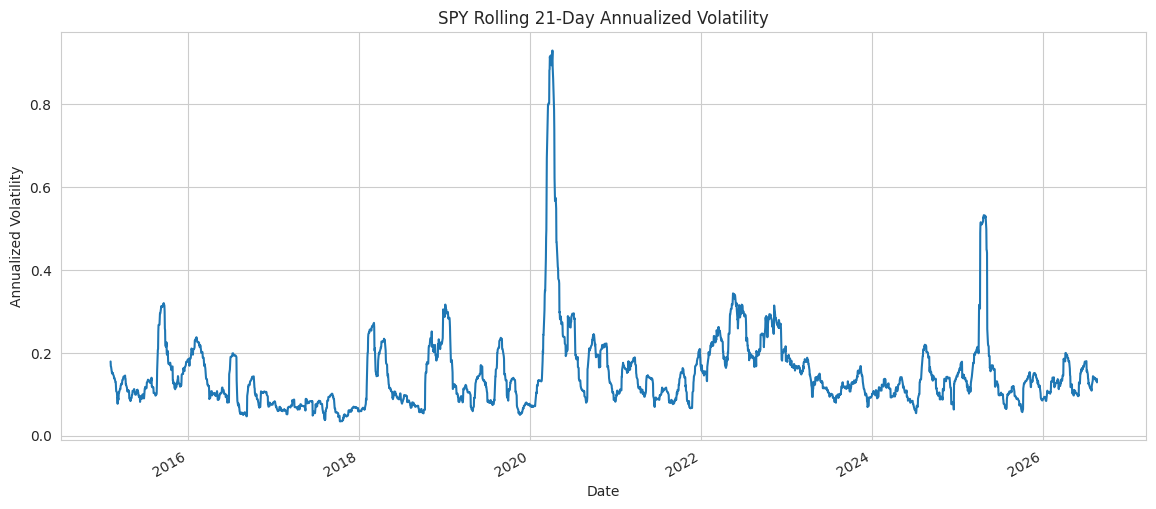

In [87]:
rolling_vol = returns.rolling(window=21).std() * np.sqrt(252)

plt.figure(figsize=(14,6))
rolling_vol["SPY"].plot(title="SPY Rolling 21-Day Annualized Volatility")
plt.ylabel("Annualized Volatility")
plt.savefig("SPY Rolling 21-Day Annualized Volatility.png", dpi=150, bbox_inches="tight")
plt.show()


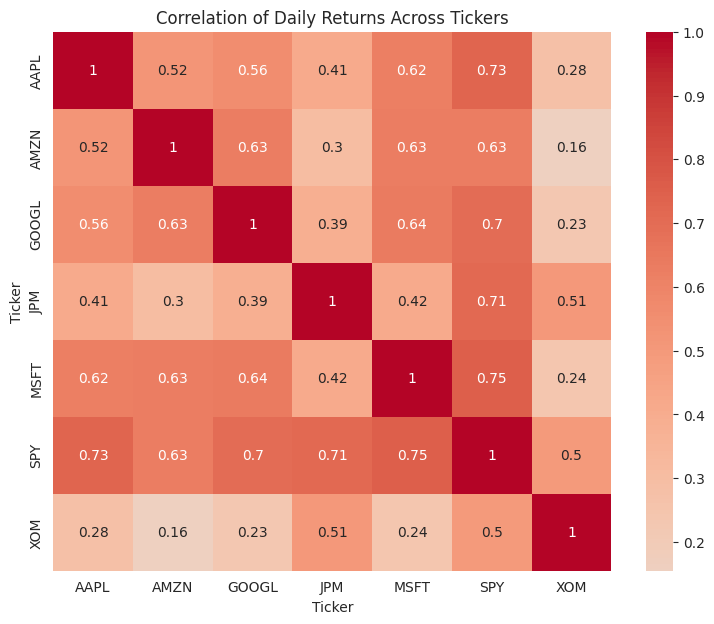

In [88]:
corr_matrix = returns.corr()

plt.figure(figsize=(9,7))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation of Daily Returns Across Tickers")
plt.savefig("Correlation of Daily Returns Across Tickers.png", dpi=150, bbox_inches="tight")
plt.show()

In [89]:
df = pd.DataFrame(index=close_prices.index)
ticker = "SPY"

df["return"] = close_prices[ticker].pct_change()
df["lag_return_1"] = df["return"].shift(1)
df["lag_return_2"] = df["return"].shift(2)
df["lag_return_5"] = df["return"].shift(5)
df["ma_5"] = close_prices[ticker].rolling(5).mean() / close_prices[ticker] - 1
df["ma_20"] = close_prices[ticker].rolling(20).mean() / close_prices[ticker] - 1
df["volatility_10"] = df["return"].rolling(10).std()
df["volume_z"] = (volumes[ticker] - volumes[ticker].rolling(20).mean()) / volumes[ticker].rolling(20).std()

delta = close_prices[ticker].diff()
gain = delta.clip(lower=0).rolling(14).mean()
loss = -delta.clip(upper=0).rolling(14).mean()
rs = gain / loss
df["rsi_14"] = 100 - (100 / (1 + rs))

# Target: next-day direction (1 = up, 0 = down)
df["target"] = (df["return"].shift(-1) > 0).astype(int)

df = df.dropna()
df.head()

,return,lag_return_1,lag_return_2,lag_return_5,ma_5,ma_20,volatility_10,volume_z,rsi_14,target
Date,,,,,,,,,,
2015-01-30,-0.012575,0.009243,-0.012824,-0.005483,0.012555,0.015706,0.010750,1.088781,39.839032,1
2015-02-02,0.012384,-0.012575,0.009243,0.002342,-0.003328,0.002412,0.010655,0.053952,48.509617,1
2015-02-03,0.014461,0.012384,-0.012575,-0.013191,-0.015485,-0.011116,0.011577,-0.988128,55.141502,0
2015-02-04,-0.003808,0.014461,0.012384,-0.012824,-0.007880,-0.006297,0.011608,-0.624708,56.060453,1
2015-02-05,0.010096,-0.003808,0.014461,0.009243,-0.013788,-0.015304,0.011038,-1.583580,63.335825,0


In [90]:
feature_cols = ["lag_return_1", "lag_return_2", "lag_return_5", "ma_5", "ma_20",
                 "volatility_10", "volume_z", "rsi_14"]

X = df[feature_cols]
y = df["target"]

split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = RandomForestClassifier(n_estimators=200, max_depth=5, class_weight="balanced", random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Baseline (always predict 'up'):", y_test.mean())
print("\n", classification_report(y_test, y_pred))

Accuracy: 0.4845360824742268
Baseline (always predict 'up'): 0.5756013745704467

               precision    recall  f1-score   support

           0       0.39      0.40      0.40       247
           1       0.55      0.55      0.55       335

    accuracy                           0.48       582
   macro avg       0.47      0.47      0.47       582
weighted avg       0.49      0.48      0.48       582



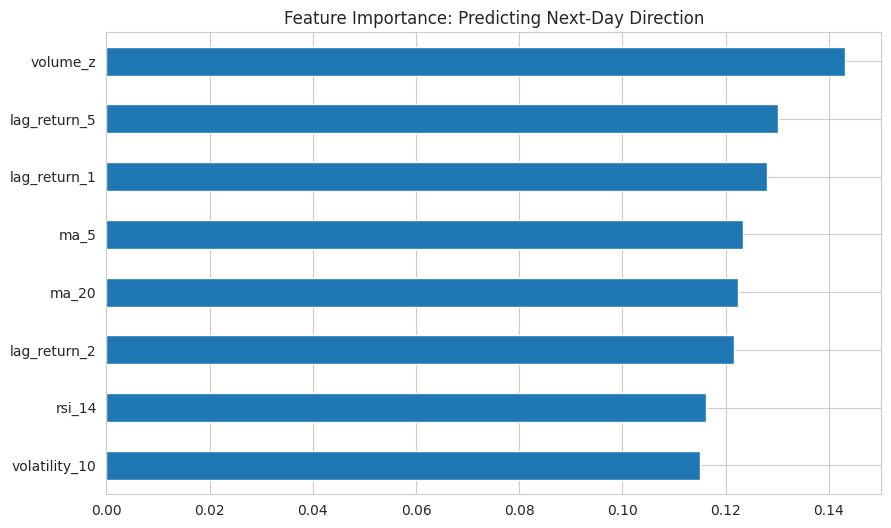

In [91]:
importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values()

plt.figure(figsize=(10,6))
importances.plot(kind="barh")
plt.title("Feature Importance: Predicting Next-Day Direction")
plt.savefig("Feature Importance: Predicting Next-Day Direction.png", dpi=150, bbox_inches="tight")
plt.show()

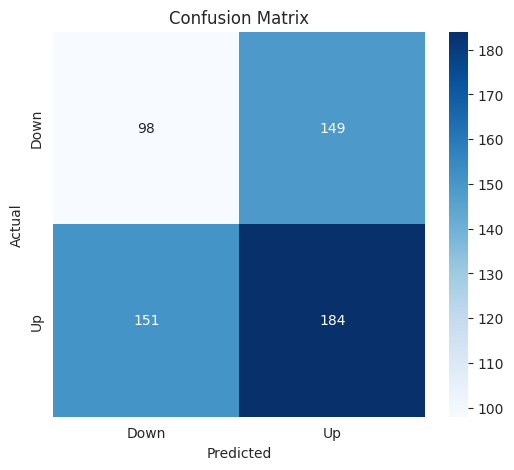

In [92]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Down","Up"], yticklabels=["Down","Up"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("Confusion Matrix.png", dpi=150, bbox_inches="tight")
plt.show()

In [93]:
test_df = df.iloc[split_idx:].copy()
test_df["prediction"] = y_pred
test_df["strategy_return"] = test_df["prediction"] * df["return"].shift(-1).iloc[split_idx:]
test_df["cum_strategy"] = (1 + test_df["strategy_return"].fillna(0)).cumprod()
test_df["cum_buy_hold"] = (1 + df["return"].shift(-1).iloc[split_idx:].fillna(0)).cumprod()

In [94]:
sharpe_strategy = test_df["strategy_return"].mean() / test_df["strategy_return"].std() * np.sqrt(252)
sharpe_bh = (df["return"].shift(-1).iloc[split_idx:]).mean() / (df["return"].shift(-1).iloc[split_idx:]).std() * np.sqrt(252)
print("Strategy Sharpe:", sharpe_strategy)
print("Buy & Hold Sharpe:", sharpe_bh)

max_dd_strategy = (test_df["cum_strategy"] / test_df["cum_strategy"].cummax() - 1).min()
max_dd_bh = (test_df["cum_buy_hold"] / test_df["cum_buy_hold"].cummax() - 1).min()
print("Strategy Max Drawdown:", max_dd_strategy)
print("Buy & Hold Max Drawdown:", max_dd_bh)

Strategy Sharpe: 0.7021689458049828
Buy & Hold Sharpe: 1.245476391159307
Strategy Max Drawdown: -0.19243515005868028
Buy & Hold Max Drawdown: -0.18755226260622682


In [95]:
test_df["trade"] = test_df["prediction"].diff().abs()
transaction_cost = 0.0005
test_df["strategy_return_net"] = test_df["strategy_return"] - test_df["trade"] * transaction_cost
test_df["cum_strategy_net"] = (1 + test_df["strategy_return_net"].fillna(0)).cumprod()


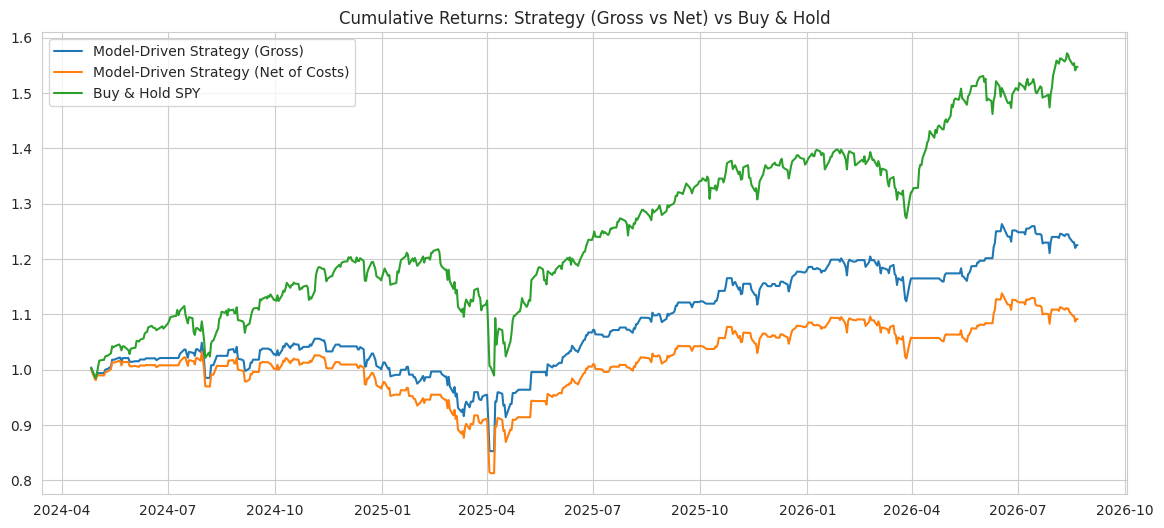

In [96]:
plt.figure(figsize=(14,6))
plt.plot(test_df.index, test_df["cum_strategy"], label="Model-Driven Strategy (Gross)")
plt.plot(test_df.index, test_df["cum_strategy_net"], label="Model-Driven Strategy (Net of Costs)")
plt.plot(test_df.index, test_df["cum_buy_hold"], label="Buy & Hold SPY")
plt.title("Cumulative Returns: Strategy (Gross vs Net) vs Buy & Hold")
plt.legend()
plt.savefig("Cumulative Returns: Strategy (Gross vs Net) vs Buy and Hold.png", dpi=150, bbox_inches="tight")
plt.show()

In [98]:
import glob, os, shutil
from google.colab import files

os.makedirs("charts", exist_ok=True)

for f in glob.glob("*.png"):
    shutil.move(f, f"charts/{f}")

shutil.make_archive("project_charts", "zip", "charts")
files.download("project_charts.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>